In [1]:
# ============================================
# 01_data_cleaning.ipynb
# Project: Customer Churn Analysis
# Purpose: Load data from PostgreSQL, clean and prepare for exploratory analysis and ML
# ============================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# ============================================
# Connect to PostgreSQL and load data
# ============================================
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv()

# Build connection string from environment variables
# Password stored in .env file — never committed to GitHub
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# Load telco table into pandas DataFrame
df = pd.read_sql('SELECT * FROM telco', engine)

# Quick confirmation
print(f"Data loaded successfully")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Data loaded successfully
Shape: 7043 rows, 21 columns

Column names:
['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


In [3]:
# ============================================
# Cell 3: First look at the data
# ============================================

# First 5 rows
print("=== FIRST 5 ROWS ===")
print(df.head())

# Data types and non-null counts
print("\n=== DATA TYPES & NULL COUNTS ===")
print(df.info())

# Basic statistics for numeric columns
print("\n=== NUMERIC COLUMN STATISTICS ===")
print(df.describe())

=== FIRST 5 ROWS ===
   customerid  gender  seniorcitizen partner dependents  tenure phoneservice  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      multiplelines internetservice onlinesecurity  ... deviceprotection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  techsupport streamingtv streamingmovies

In [4]:
# ============================================
# Cell 4: Data Cleaning
# Based on issues identified in:
# - 00_data_profiling.sql
# - df.info() and df.describe() above
# ============================================

# --- Fix 1: Convert totalcharges to numeric ---
# Issue: loaded as str due to 11 blank space values
# Treatment: strip whitespace, convert to float, blank spaces become NaN then fill with 0
df['totalcharges'] = pd.to_numeric(
    df['totalcharges'].str.strip(),
    errors='coerce'
).fillna(0)

print(f"Fix 1 complete: totalcharges converted to numeric")
print(f"dtype is now: {df['totalcharges'].dtype}")


# --- Fix 2: Convert churn to binary (0/1) ---
# Issue: churn is Yes/No text — ML models need numbers
# Treatment: map Yes → 1, No → 0
df['churn'] = df['churn'].map({'Yes': 1, 'No': 0})

print(f"\nFix 2 complete: churn converted to binary")
print(f"Churn value counts:\n{df['churn'].value_counts()}")


# --- Fix 3: Standardise column names ---
# Issue: all lowercase from PostgreSQL — confirm consistent
df.columns = df.columns.str.lower().str.strip()

print(f"\nFix 3 complete: column names standardised")


# --- Fix 4: Drop customerID ---
# Issue: customerID is an identifier not a feature ML models don't need it and it adds noise
df = df.drop('customerid', axis=1)

print(f"\nFix 4 complete: customerid dropped")
print(f"New shape: {df.shape[0]} rows, {df.shape[1]} columns")


# --- Verify all fixes ---
print(f"\n=== CLEANING COMPLETE ===")
print(f"Shape: {df.shape}")
print(f"\nData types after cleaning:")
print(df.dtypes)
print(f"\nNull values after cleaning:")
print(df.isnull().sum())

Fix 1 complete: totalcharges converted to numeric
dtype is now: float64

Fix 2 complete: churn converted to binary
Churn value counts:
churn
0    5174
1    1869
Name: count, dtype: int64

Fix 3 complete: column names standardised

Fix 4 complete: customerid dropped
New shape: 7043 rows, 20 columns

=== CLEANING COMPLETE ===
Shape: (7043, 20)

Data types after cleaning:
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                 int64
dtype: object

Null values after cleaning:
gender              0
sen

In [5]:
# ============================================
# Cell 5: Cleaning Verification
# Confirm all fixes worked correctly and
# data matches our SQL findings
# ============================================

# --- Check 1: totalcharges distribution ---
print("=== TOTALCHARGES AFTER CONVERSION ===")
print(df['totalcharges'].describe())
print(f"\nZero values (our 11 blank customers): {(df['totalcharges'] == 0).sum()}")

# --- Check 2: Churn distribution ---
print("\n=== CHURN DISTRIBUTION ===")
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100
print(f"Retained (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"Churned  (1): {churn_counts[1]} ({churn_pct[1]:.1f}%)")

# --- Check 3: Verify against SQL findings ---
print("\n=== VERIFICATION AGAINST SQL FINDINGS ===")
print(f"Total rows:          {len(df)} (expected 7,043)")
print(f"Total columns:       {df.shape[1]} (expected 20 — customerid dropped)")
print(f"Overall churn rate:  {df['churn'].mean() * 100:.1f}% (expected 26.5%)")
print(f"Avg monthly charges: ${df['monthlycharges'].mean():.2f} (expected $64.76)")
print(f"Avg tenure:          {df['tenure'].mean():.1f} months (expected 32.4)")
print(f"Senior citizens:     {df['seniorcitizen'].mean() * 100:.1f}% (expected 16.2%)")

# --- Check 4: No remaining nulls ---
print("\n=== NULL CHECK ===")
nulls = df.isnull().sum()
if nulls.sum() == 0:
    print("✓ No null values found — data is clean")
else:
    print("⚠️ Nulls found:")
    print(nulls[nulls > 0])

# --- Check 5: Final data snapshot ---
print("\n=== FINAL DATA SNAPSHOT ===")
print(df.head())

=== TOTALCHARGES AFTER CONVERSION ===
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: totalcharges, dtype: float64

Zero values (our 11 blank customers): 11

=== CHURN DISTRIBUTION ===
Retained (0): 5174 (73.5%)
Churned  (1): 1869 (26.5%)

=== VERIFICATION AGAINST SQL FINDINGS ===
Total rows:          7043 (expected 7,043)
Total columns:       20 (expected 20 — customerid dropped)
Overall churn rate:  26.5% (expected 26.5%)
Avg monthly charges: $64.76 (expected $64.76)
Avg tenure:          32.4 months (expected 32.4)
Senior citizens:     16.2% (expected 16.2%)

=== NULL CHECK ===
✓ No null values found — data is clean

=== FINAL DATA SNAPSHOT ===
   gender  seniorcitizen partner dependents  tenure phoneservice  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male      

In [6]:
# ============================================
# Cell 6: Visualisation Setup
# Set consistent style for all charts
# ============================================

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Colour palette — consistent across all charts
CHURN_COLORS = {'Churned': '#e74c3c', 'Retained': '#2ecc71'}
PALETTE = 'Set2'

print("Visualisation style set successfully")

Visualisation style set successfully


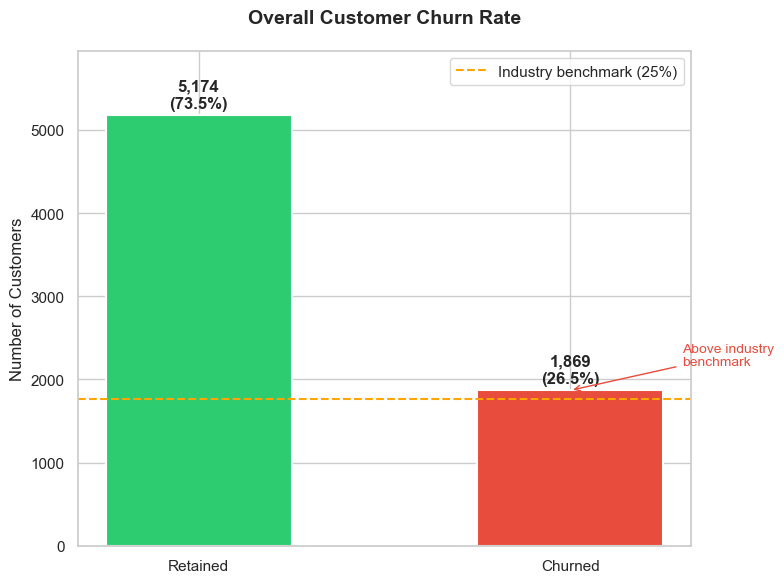

In [7]:
# ============================================
# Cell 7: Chart 1 — Overall Churn Rate
# SQL Finding: 26.5% of customers churned
# Above 15-25% telecom industry benchmark
# ============================================

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate churn counts and percentages
churn_data = df['churn'].value_counts()
churn_labels = ['Retained', 'Churned']
churn_colors = ['#2ecc71', '#e74c3c']
churn_values = [churn_data[0], churn_data[1]]

# Bar chart
bars = ax.bar(churn_labels, churn_values, 
              color=churn_colors, 
              width=0.5,
              edgecolor='white',
              linewidth=1.5)

# Add value labels on top of each bar
for bar, value in zip(bars, churn_values):
    percentage = value / len(df) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{value:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

# Labels and title
ax.set_title('Overall Customer Churn Rate', pad=20)
ax.set_ylabel('Number of Customers')
ax.set_xlabel('')
ax.set_ylim(0, max(churn_values) * 1.15)

# Add industry benchmark line
ax.axhline(y=len(df) * 0.25, color='orange', 
           linestyle='--', linewidth=1.5,
           label='Industry benchmark (25%)')
ax.legend()

# Add annotation
ax.annotate(
    'Above industry\nbenchmark',
    xy=(1, churn_data[1]),
    xytext=(1.3, churn_data[1] + 300),
    fontsize=10,
    color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

plt.tight_layout()
plt.savefig('../outputs/figures/01_overall_churn_rate.png', 
            dpi=150, bbox_inches='tight')
plt.show()

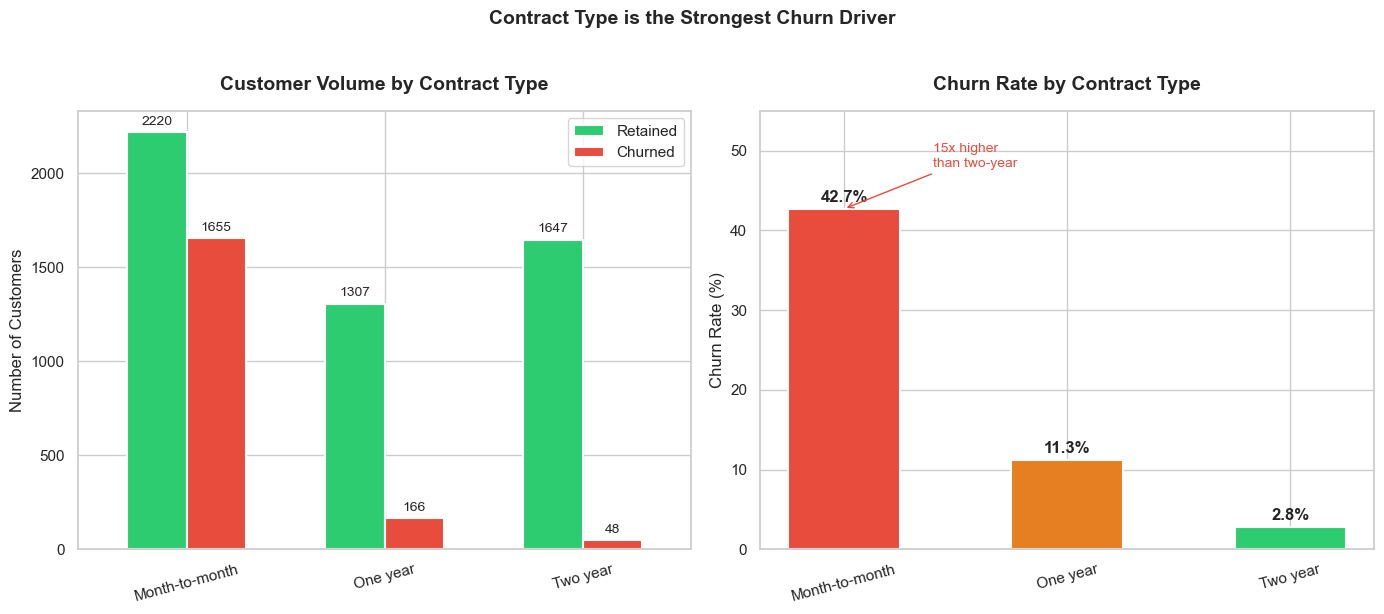

Chart 2 saved to outputs/figures/


In [8]:
# ============================================
# Cell 8: Chart 2 — Churn by Contract Type
# SQL Finding: Month-to-month churns at 42.71% vs 2.83% for two-year contracts — 15x difference
# Strongest single driver of churn in the dataset
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left chart: Customer volume by contract ---
contract_counts = df.groupby('contract')['churn'].value_counts().unstack()
contract_counts.columns = ['Retained', 'Churned']
contract_order = ['Month-to-month', 'One year', 'Two year']
contract_counts = contract_counts.reindex(contract_order)

contract_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

axes[0].set_title('Customer Volume by Contract Type', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Retained', 'Churned'])

# Add value labels
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=10)

# --- Right chart: Churn RATE by contract ---
churn_rate = df.groupby('contract')['churn'].mean() * 100
churn_rate = churn_rate.reindex(contract_order)

bars = axes[1].bar(
    contract_order,
    churn_rate,
    color=['#e74c3c', '#e67e22', '#2ecc71'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add percentage labels on bars
for bar, rate in zip(bars, churn_rate):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

axes[1].set_title('Churn Rate by Contract Type', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 55)

# Add 15x annotation
axes[1].annotate(
    '15x higher\nthan two-year',
    xy=(0, churn_rate['Month-to-month']),
    xytext=(0.4, 48),
    fontsize=10,
    color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

plt.suptitle('Contract Type is the Strongest Churn Driver',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/02_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved to outputs/figures/")

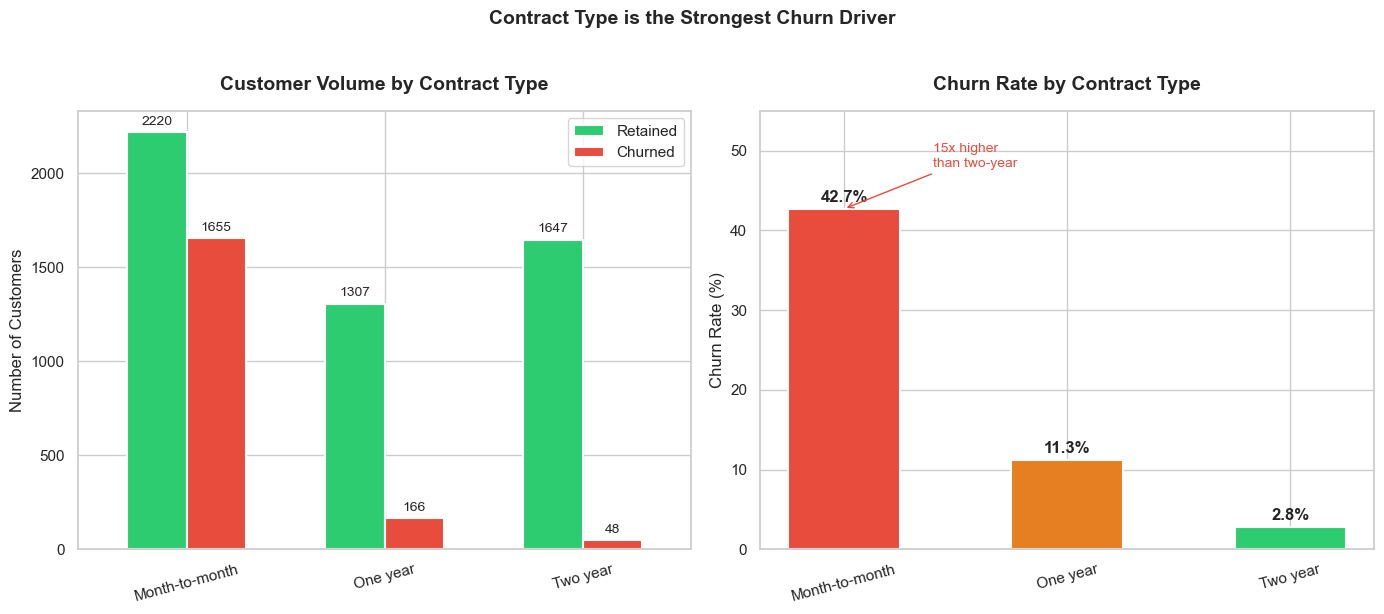

Chart 2 saved to outputs/figures/


In [9]:
# ============================================
# Cell 8: Chart 2 — Churn by Contract Type
# SQL Finding: Month-to-month churns at 42.71% vs 2.83% for two-year contracts — 15x difference
# Strongest single driver of churn in the dataset
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left chart: Customer volume by contract ---
contract_counts = df.groupby('contract')['churn'].value_counts().unstack()
contract_counts.columns = ['Retained', 'Churned']
contract_order = ['Month-to-month', 'One year', 'Two year']
contract_counts = contract_counts.reindex(contract_order)

contract_counts.plot(
    kind='bar',
    ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

axes[0].set_title('Customer Volume by Contract Type', pad=15)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Retained', 'Churned'])

# Add value labels
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3, fontsize=10)

# --- Right chart: Churn RATE by contract ---
churn_rate = df.groupby('contract')['churn'].mean() * 100
churn_rate = churn_rate.reindex(contract_order)

bars = axes[1].bar(
    contract_order,
    churn_rate,
    color=['#e74c3c', '#e67e22', '#2ecc71'],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add percentage labels on bars
for bar, rate in zip(bars, churn_rate):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

axes[1].set_title('Churn Rate by Contract Type', pad=15)
axes[1].set_xlabel('')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].set_ylim(0, 55)

# Add 15x annotation
axes[1].annotate(
    '15x higher\nthan two-year',
    xy=(0, churn_rate['Month-to-month']),
    xytext=(0.4, 48),
    fontsize=10,
    color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

plt.suptitle('Contract Type is the Strongest Churn Driver',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/02_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved to outputs/figures/")

Tenure churn rates:
              total  churned  churn_rate
tenure_group                            
0-12 months    2186     1037   47.438243
13-24 months   1024      294   28.710938
25-48 months   1594      325   20.388959
48+ months     2239      213    9.513176


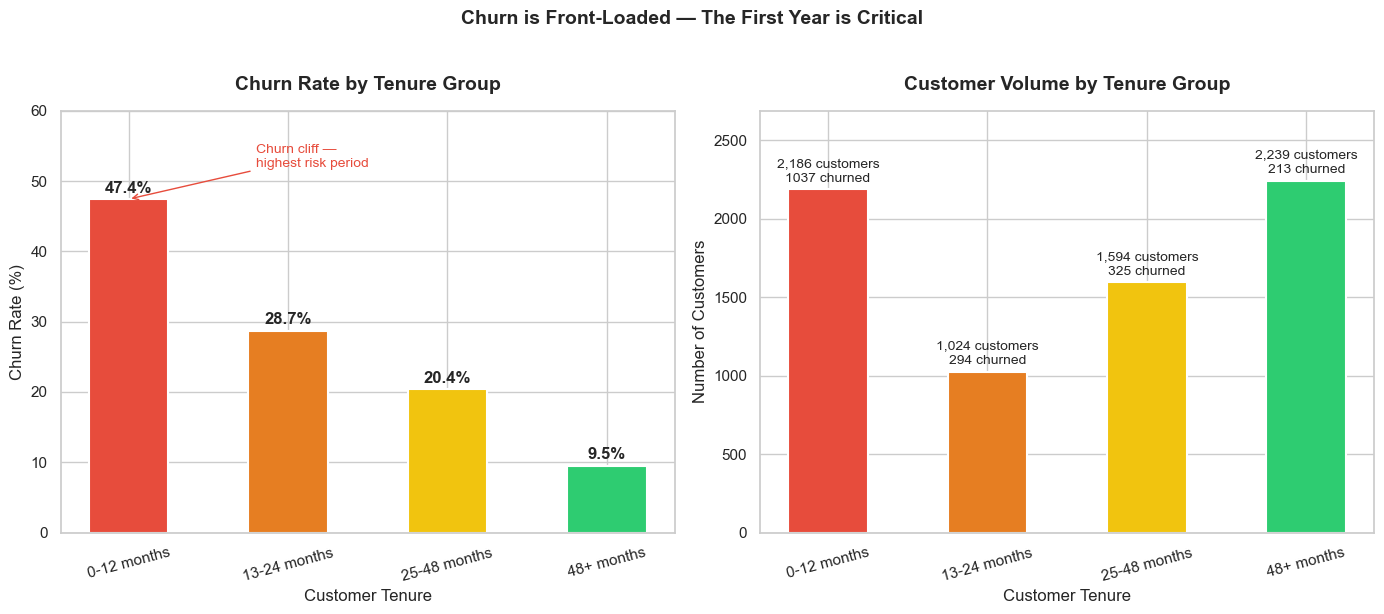

Chart 3 saved to outputs/figures/


In [10]:
# ============================================
# Cell 9: Chart 3 — Churn by Tenure Group
# SQL Finding: Churn is front-loaded — 0-12 month customers churn at ~47% vs ~9% for 48+ months
# Retention problem is an onboarding problem
# ============================================

# --- Prepare data ---
# Create tenure groups — same bins as SQL Query 3
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', 
            '25-48 months', '48+ months'],
    include_lowest=True
)

# Calculate churn rate per tenure group
tenure_churn = df.groupby('tenure_group', observed=True)['churn'].agg(
    total='count',
    churned='sum'
)
tenure_churn['churn_rate'] = (
    tenure_churn['churned'] / tenure_churn['total'] * 100
)

print("Tenure churn rates:")
print(tenure_churn)

# --- Build chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — churn rate by tenure group
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = axes[0].bar(
    tenure_churn.index,
    tenure_churn['churn_rate'],
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add percentage labels
for bar, rate in zip(bars, tenure_churn['churn_rate']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

axes[0].set_title('Churn Rate by Tenure Group', pad=15)
axes[0].set_xlabel('Customer Tenure')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 60)
axes[0].tick_params(axis='x', rotation=15)

# Add churn cliff annotation
axes[0].annotate(
    'Churn cliff —\nhighest risk period',
    xy=(0, tenure_churn['churn_rate'].iloc[0]),
    xytext=(0.8, 52),
    fontsize=10,
    color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

# Right — customer volume by tenure group
axes[1].bar(
    tenure_churn.index,
    tenure_churn['total'],
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add volume labels
for i, (total, churned) in enumerate(
    zip(tenure_churn['total'], tenure_churn['churned'])
):
    axes[1].text(
        i, total + 30,
        f'{total:,} customers\n{churned} churned',
        ha='center',
        va='bottom',
        fontsize=10
    )

axes[1].set_title('Customer Volume by Tenure Group', pad=15)
axes[1].set_xlabel('Customer Tenure')
axes[1].set_ylabel('Number of Customers')
axes[1].set_ylim(0, max(tenure_churn['total']) * 1.2)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle(
    'Churn is Front-Loaded — The First Year is Critical',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/03_churn_by_tenure.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved to outputs/figures/")

Internet service churn rates (sorted):
                 total  churned  churn_rate  retained
internetservice                                      
Fiber optic       3096     1297   41.892765      1799
DSL               2421      459   18.959108      1962
No                1526      113    7.404980      1413


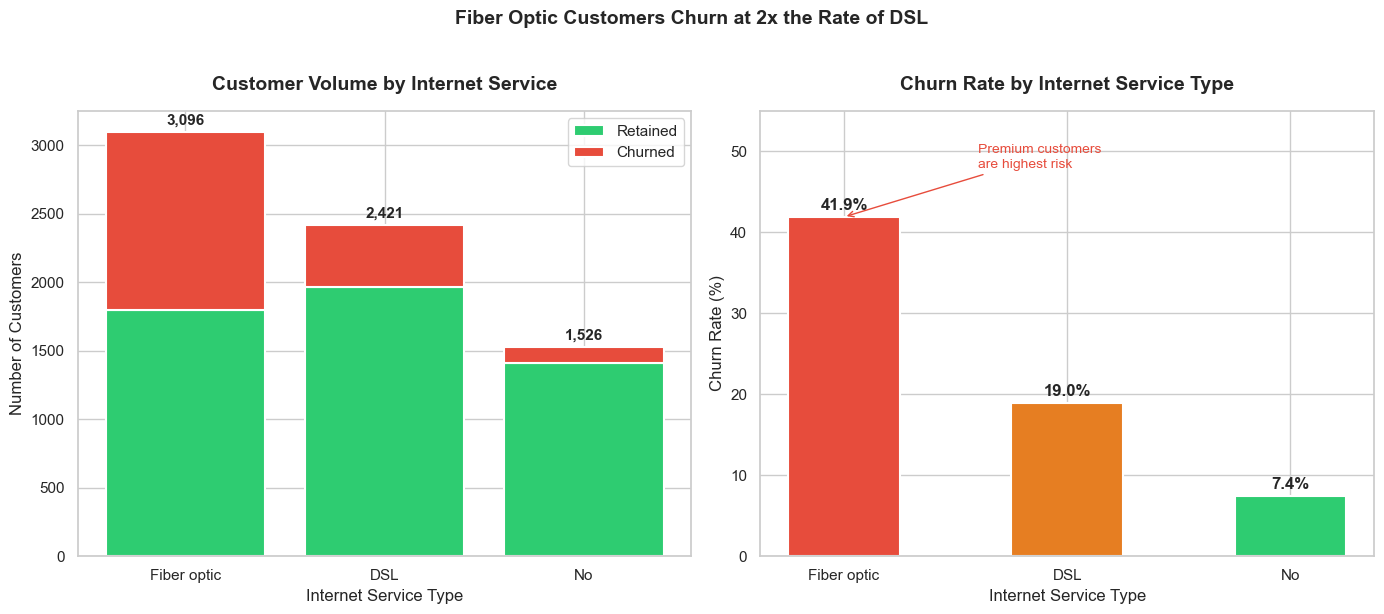

Chart 4 saved to outputs/figures/


In [11]:
# ============================================
# Cell 10: Chart 4 — Churn by Internet Service
# SQL Finding: Fiber optic customers churn at ~41% vs ~19% for DSL and ~7% for no internet
# Premium customers are highest risk
# ============================================

# --- Prepare data ---
internet_churn = df.groupby('internetservice')['churn'].agg(
    total='count',
    churned='sum'
)
internet_churn['churn_rate'] = (
    internet_churn['churned'] / internet_churn['total'] * 100
)
internet_churn['retained'] = (
    internet_churn['total'] - internet_churn['churned']
)

# Sort dynamically by churn rate — highest first
internet_churn = internet_churn.sort_values('churn_rate', ascending=False)
service_order = internet_churn.index.tolist()

print("Internet service churn rates (sorted):")
print(internet_churn)

# --- Build chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left — stacked bar showing volume + composition ---
axes[0].bar(
    service_order,
    internet_churn['retained'],
    color='#2ecc71',
    label='Retained',
    edgecolor='white',
    linewidth=1.5
)
axes[0].bar(
    service_order,
    internet_churn['churned'],
    bottom=internet_churn['retained'],
    color='#e74c3c',
    label='Churned',
    edgecolor='white',
    linewidth=1.5
)

axes[0].set_title('Customer Volume by Internet Service', pad=15)
axes[0].set_xlabel('Internet Service Type')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Add total labels on top of stacked bars
for i, total in enumerate(internet_churn['total']):
    axes[0].text(
        i, total + 30,
        f'{total:,}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

# --- Right — churn rate comparison ---
# Generate colors dynamically based on number of categories
colors = ['#e74c3c', '#e67e22', '#2ecc71'][:len(service_order)]

bars = axes[1].bar(
    service_order,
    internet_churn['churn_rate'],
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add percentage labels
for bar, rate in zip(bars, internet_churn['churn_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

axes[1].set_title('Churn Rate by Internet Service Type', pad=15)
axes[1].set_xlabel('Internet Service Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 55)

# Dynamic annotation — always points to highest churn
axes[1].annotate(
    'Premium customers\nare highest risk',
    xy=(0, internet_churn['churn_rate'].iloc[0]),
    xytext=(0.6, 48),
    fontsize=10,
    color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

plt.suptitle(
    'Fiber Optic Customers Churn at 2x the Rate of DSL',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/04_churn_by_internet_service.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved to outputs/figures/")

Payment method churn rates (sorted):
                           total  churned  churn_rate  retained
paymentmethod                                                  
Electronic check            2365     1071   45.285412      1294
Mailed check                1612      308   19.106700      1304
Bank transfer (automatic)   1544      258   16.709845      1286
Credit card (automatic)     1522      232   15.243101      1290


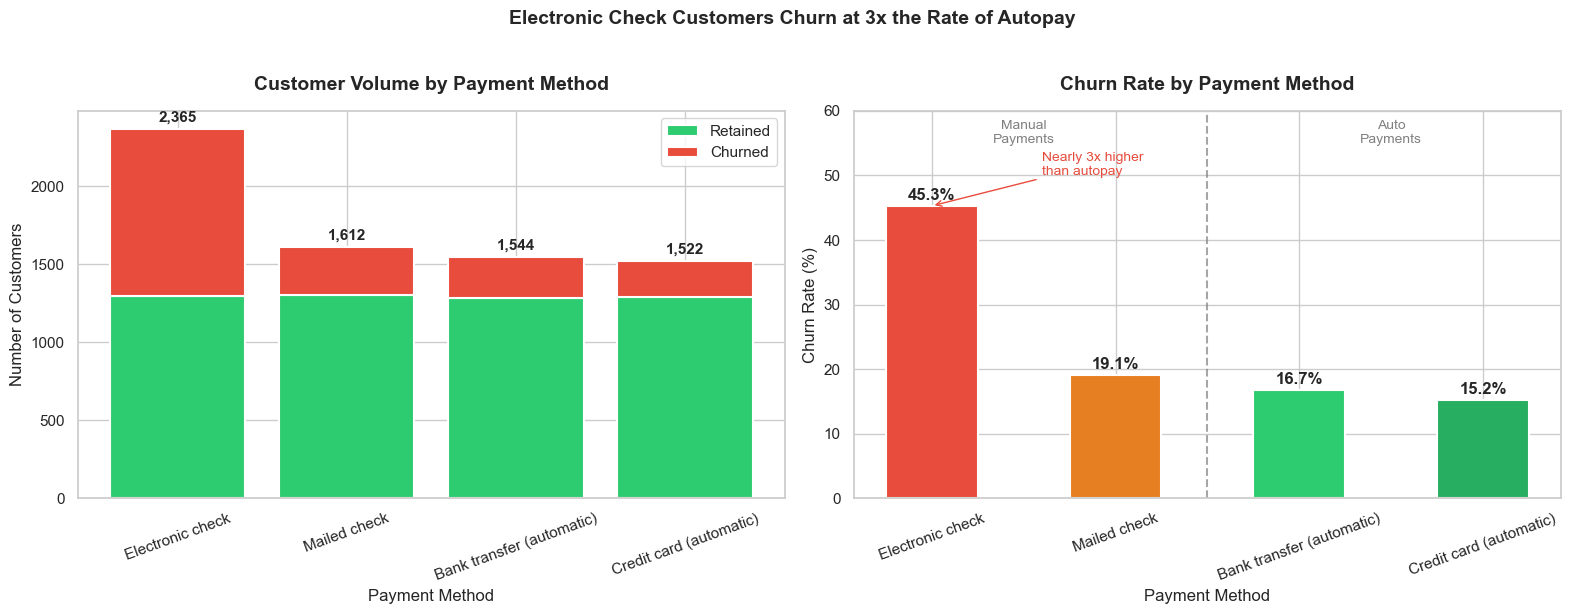

Chart 5 saved to outputs/figures/


In [12]:
# ============================================
# Cell 11: Chart 5 — Churn by Payment Method
# SQL Finding: Electronic check customers churn at 45% — nearly 3x autopay customers at 15-17%
# Payment method is a proxy for commitment level
# ============================================

# --- Prepare data ---
payment_churn = df.groupby('paymentmethod')['churn'].agg(
    total='count',
    churned='sum'
)
payment_churn['churn_rate'] = (
    payment_churn['churned'] / payment_churn['total'] * 100
)
payment_churn['retained'] = (
    payment_churn['total'] - payment_churn['churned']
)

# Sort dynamically by churn rate — highest first
payment_churn = payment_churn.sort_values('churn_rate', ascending=False)
payment_order = payment_churn.index.tolist()

print("Payment method churn rates (sorted):")
print(payment_churn)

# --- Build chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left — stacked bar showing volume + composition ---
axes[0].bar(
    payment_order,
    payment_churn['retained'],
    color='#2ecc71',
    label='Retained',
    edgecolor='white',
    linewidth=1.5
)
axes[0].bar(
    payment_order,
    payment_churn['churned'],
    bottom=payment_churn['retained'],
    color='#e74c3c',
    label='Churned',
    edgecolor='white',
    linewidth=1.5
)

axes[0].set_title('Customer Volume by Payment Method', pad=15)
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

# Add total labels
for i, total in enumerate(payment_churn['total']):
    axes[0].text(
        i, total + 30,
        f'{total:,}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

# --- Right — churn rate comparison ---
# Color encode — red for manual, green for auto
colors = ['#e74c3c', '#e67e22', '#2ecc71', '#27ae60']
bars = axes[1].bar(
    payment_order,
    payment_churn['churn_rate'],
    color=colors[:len(payment_order)],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add percentage labels
for bar, rate in zip(bars, payment_churn['churn_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{rate:.1f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

axes[1].set_title('Churn Rate by Payment Method', pad=15)
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_ylim(0, 60)
axes[1].tick_params(axis='x', rotation=20)

# Add divider line between manual and auto payments
axes[1].axvline(x=1.5, color='gray', linestyle='--',
                linewidth=1.5, alpha=0.7)
axes[1].text(0.5, 55, 'Manual\nPayments',
             ha='center', fontsize=10, color='gray')
axes[1].text(2.5, 55, 'Auto\nPayments',
             ha='center', fontsize=10, color='gray')

# Add 3x annotation
axes[1].annotate(
    'Nearly 3x higher\nthan autopay',
    xy=(0, payment_churn['churn_rate'].iloc[0]),
    xytext=(0.6, 50),
    fontsize=10,
    color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

plt.suptitle(
    'Electronic Check Customers Churn at 3x the Rate of Autopay',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/05_churn_by_payment_method.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved to outputs/figures/")

Revenue at risk by contract type:
                churned_customers  monthly_revenue_lost  \
contract                                                  
Month-to-month               1655             120847.10   
One year                      166              14118.45   
Two year                       48               4165.30   

                annual_revenue_at_risk  pct_of_total  
contract                                              
Month-to-month               1450165.2     86.858594  
One year                      169421.4     10.147606  
Two year                       49983.6      2.993800  

Total annual revenue at risk: $1,669,570.20


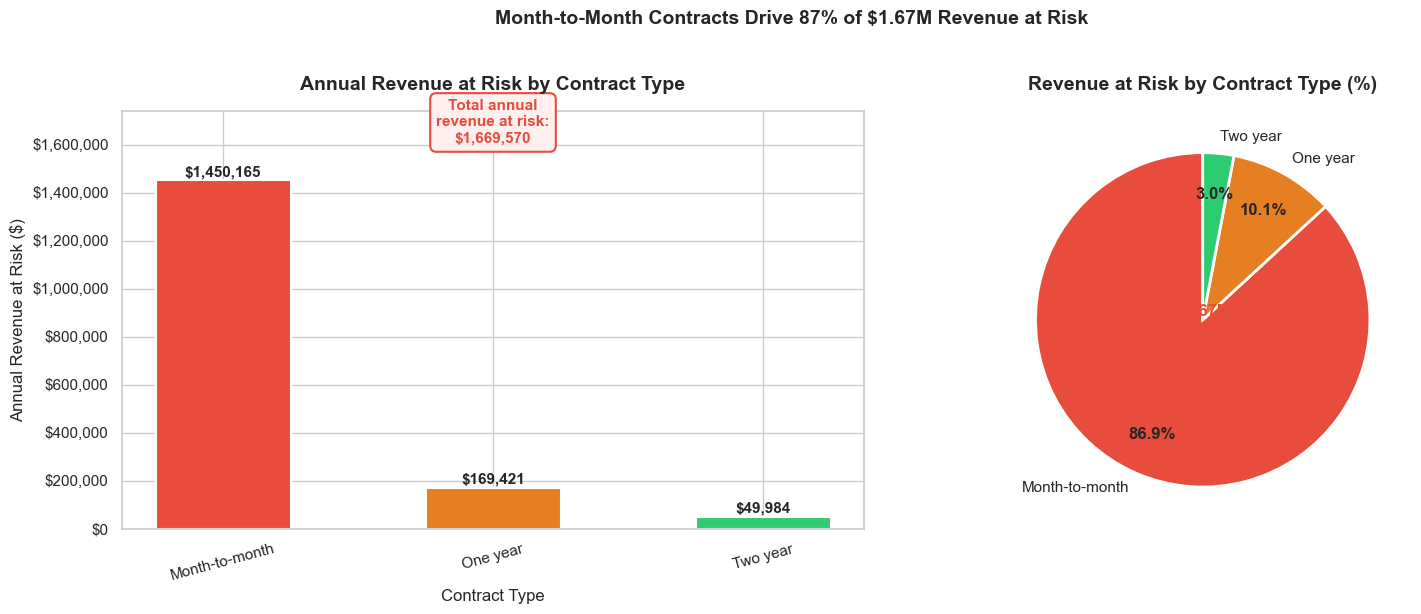

Chart 6 saved to outputs/figures/


In [13]:
# ============================================
# Cell 12: Chart 6 — Revenue at Risk
# SQL Finding: $1.67M annual revenue at risk
# Month-to-month accounts for 87% of total
# The dollar figure that gets CFO attention
# ============================================

# --- Prepare data ---
revenue_risk = df[df['churn'] == 1].groupby('contract').agg(
    churned_customers=('churn', 'count'),
    monthly_revenue_lost=('monthlycharges', 'sum')
)
revenue_risk['annual_revenue_at_risk'] = (
    revenue_risk['monthly_revenue_lost'] * 12
)
revenue_risk['pct_of_total'] = (
    revenue_risk['annual_revenue_at_risk'] /
    revenue_risk['annual_revenue_at_risk'].sum() * 100
)

# Sort by revenue at risk
revenue_risk = revenue_risk.sort_values(
    'annual_revenue_at_risk', ascending=False
)

print("Revenue at risk by contract type:")
print(revenue_risk)
print(f"\nTotal annual revenue at risk: "
      f"${revenue_risk['annual_revenue_at_risk'].sum():,.2f}")

# --- Build chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

contract_order = revenue_risk.index.tolist()
colors = ['#e74c3c', '#e67e22', '#2ecc71']

# --- Left — annual revenue at risk bar chart ---
bars = axes[0].bar(
    contract_order,
    revenue_risk['annual_revenue_at_risk'],
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

# Add dollar labels
for bar, value in zip(bars, revenue_risk['annual_revenue_at_risk']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

axes[0].set_title('Annual Revenue at Risk by Contract Type', pad=15)
axes[0].set_xlabel('Contract Type')
axes[0].set_ylabel('Annual Revenue at Risk ($)')
axes[0].set_ylim(0, max(revenue_risk['annual_revenue_at_risk']) * 1.2)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)
axes[0].tick_params(axis='x', rotation=15)

# Add total as floating text box
total = revenue_risk['annual_revenue_at_risk'].sum()
axes[0].text(
    1, max(revenue_risk['annual_revenue_at_risk']) * 1.1,
    f'Total annual\nrevenue at risk:\n${total:,.0f}',
    ha='center',
    va='bottom',
    fontweight='bold',
    fontsize=11,
    color='#e74c3c',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#fdf0ee',
              edgecolor='#e74c3c',
              linewidth=1.5)
)

# --- Right — pie chart showing % composition ---
wedge_colors = ['#e74c3c', '#e67e22', '#2ecc71']
wedges, texts, autotexts = axes[1].pie(
    revenue_risk['annual_revenue_at_risk'],
    labels=contract_order,
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

axes[1].set_title('Revenue at Risk by Contract Type (%)', pad=15)

# Add centre annotation
axes[1].text(
    0, 0,
    f'${total/1e6:.2f}M\ntotal at risk',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    color='#e74c3c'
)

plt.suptitle(
    'Month-to-Month Contracts Drive 87% of $1.67M Revenue at Risk',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/figures/06_revenue_at_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved to outputs/figures/")